# Customer Lifetime Value Prediction — Modeling

## Objective
The goal of this notebook is to train and evaluate a machine learning system that predicts future customer lifetime value (CLV) from historical customer behavior.

This notebook will:

- load the customer-level modeling table
- define features and targets
- build a single-stage baseline regression model
- identify limitations caused by zero inflation and target skew
- implement an improved two-stage CLV architecture
- evaluate classification, regression, and final expected CLV performance
- interpret model drivers
- save final model artifacts for deployment

## Modeling Principle
The future CLV target is:
- highly right-skewed
- zero-inflated
- difficult to model accurately with a single regression model

To address this, the final modeling approach decomposes the problem into:

1. **Classification** — predict whether a customer will return  
2. **Regression** — predict customer value conditional on return  

The final CLV prediction is computed as:

**Expected CLV = P(return) × E(value | return)**

This mirrors a more realistic production modeling strategy.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    roc_auc_score
)

from xgboost import XGBRegressor, XGBClassifier
import joblib
import shap

c:\Users\USER\Documents\Machine Learning Projects\customer-life-time-value\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Modeling Dataset

In this section, we load the final customer-level modeling table created during feature engineering.

Each row represents one customer and contains:
- historical customer behavior features
- future order activity
- future customer lifetime value

This forms the input to the modeling stage.

In [2]:
df_model = pd.read_csv("../data/processed/customer_modeling_table.csv")
df_model.head()

,customer_id,total_revenue,total_orders,total_items,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order,active_days,avg_days_between_orders,revenue_per_day,orders_per_day,recency_ratio,items_per_order,future_orders,future_clv
0,12347,1603.68,3,956,25.057500,2.877344,50,1,116,39,534.56,3,58.0,13.824828,0.025862,0.336207,318.666667,2,1519.14
1,12348,367.00,1,269,73.400000,8.920000,5,1,0,158,367.00,1,0.0,367.000000,1.000000,158.000000,269.000000,1,310.00
2,12352,280.66,2,127,18.710667,4.892000,8,1,5,172,140.33,2,5.0,56.132000,0.400000,34.400000,63.500000,3,944.23
3,12353,89.00,1,20,22.250000,6.075000,4,1,0,114,89.00,1,0.0,89.000000,1.000000,114.000000,20.000000,0,0.00
4,12354,1079.40,1,530,18.610345,4.503793,58,1,0,142,1079.40,1,0.0,1079.400000,1.000000,142.000000,530.000000,0,0.00


### Interpretation

The modeling dataset is structured correctly for supervised learning:
- one row per customer
- historical behavioral features as predictors
- future CLV as the business target

This reflects how a real production model would score customers based on past behavior.

## 2. Validate Modeling Dataset Quality

Before training, it is important to verify that the modeling table is complete and internally consistent.

We will check:
- row count
- column count
- missing values
- uniqueness of customer records

In [3]:
model_input_summary = pd.DataFrame({
    "metric": ["rows", "columns", "missing_values_total", "unique_customers"],
    "value": [
        len(df_model),
        df_model.shape[1],
        df_model.isna().sum().sum(),
        df_model["customer_id"].nunique()
    ]
})

model_input_summary

,metric,value
0,rows,2784
1,columns,19
2,missing_values_total,0
3,unique_customers,2784


### Interpretation

The modeling table contains:

- **2,784 rows**
- **19 columns**
- **0 missing values**
- **2,784 unique customers**

This confirms that the dataset is clean and ready for model training.

There is one row per customer, no missing feature values, and no evidence of duplicate customer records in the modeling table.

## 3. Define Modeling Features and Regression Target

The historical customer behavior variables will be used as model inputs.

For regression, we define:
- `y_raw` = future CLV on the original business scale
- `y` = `log1p(future_clv)` for more stable regression learning

The log transformation is used because future CLV is highly right-skewed.

In [8]:
feature_cols = [
    "total_revenue",
    "total_orders",
    "total_items",
    "avg_line_revenue",
    "avg_unit_price",
    "unique_products",
    "unique_countries",
    "customer_tenure_days",
    "recency_days",
    "avg_revenue_per_order",
    "active_days",
    "avg_days_between_orders",
    "revenue_per_day",
    "orders_per_day",
    "recency_ratio",
    "items_per_order",
]

X = df_model[feature_cols].copy()
y_raw = df_model["future_clv"].copy()
y = np.log1p(y_raw)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2784, 16)
y shape: (2784,)


### Interpretation

The modeling input includes:
- **12 historical customer features**
- **2,784 target values**

The log-transformed target is used because it:
- reduces the influence of extreme outliers
- stabilizes the variance of the target
- makes regression learning more tractable

Predictions can later be converted back to the original scale using `expm1`.

## 4. Train/Test Split for Single-Stage Regression Benchmark

Before moving to the final two-stage architecture, we first train a conventional single-stage regression model.

This provides a benchmark and helps quantify the improvement from the more advanced architecture.

In [9]:
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y, y_raw,
    test_size=0.2,
    random_state=42
)

split_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(X_train), len(X_test)]
})

split_summary

,dataset,rows
0,train,2227
1,test,557


### Interpretation

The train/test split produced:
- **2,227 customers** in the training set
- **557 customers** in the test set

This enables proper out-of-sample evaluation and gives a realistic estimate of how the model will perform on unseen customers.

## 5. Baseline Regression Model

A baseline model is trained using `DummyRegressor(strategy="mean")`.

This model predicts the mean transformed target for every customer and does not use any behavioral information.

It serves as a minimum benchmark that any useful ML model should exceed.

In [10]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

baseline_pred_log = baseline_model.predict(X_test)
baseline_pred_raw = np.expm1(baseline_pred_log)

baseline_metrics = {
    "model": "DummyRegressor_mean",
    "mae_raw": mean_absolute_error(y_test_raw, baseline_pred_raw),
    "rmse_raw": np.sqrt(mean_squared_error(y_test_raw, baseline_pred_raw)),
    "r2_log": r2_score(y_test, baseline_pred_log)
}

baseline_metrics

{'model': 'DummyRegressor_mean',
 'mae_raw': 1027.116370471742,
 'rmse_raw': np.float64(5436.311137722947),
 'r2_log': -2.0277700165882706e-05}

### Interpretation

The baseline model produces:
- **MAE ≈ 1027.12**
- **RMSE ≈ 5436.31**
- **R² ≈ 0**

The baseline model establishes a naive reference point.

Because it predicts the same expected value for all customers, it cannot capture meaningful behavioral differences between:
- low-value customers
- medium-value customers
- high-value customers

This benchmark helps determine whether the advanced models are learning real signal from historical behavior.

## 6. Single-Stage XGBoost Regression Benchmark

Next, a single-stage XGBoost regression model is trained on the full customer base.

This model predicts `log1p(future_clv)` directly from historical features.

It serves as a stronger benchmark before implementing the final two-stage architecture.

In [11]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred_log = xgb_model.predict(X_test)
xgb_pred_raw = np.expm1(xgb_pred_log)

xgb_metrics = {
    "model": "XGBRegressor_single_stage",
    "mae_raw": mean_absolute_error(y_test_raw, xgb_pred_raw),
    "rmse_raw": np.sqrt(mean_squared_error(y_test_raw, xgb_pred_raw)),
    "r2_log": r2_score(y_test, xgb_pred_log)
}

xgb_metrics

{'model': 'XGBRegressor_single_stage',
 'mae_raw': 800.20944740809,
 'rmse_raw': np.float64(4325.249483514581),
 'r2_log': 0.19148373646608596}

### Interpretation

The XGBoost model produces:
- **MAE ≈ 820.80**
- **RMSE ≈ 4371.60**
- **R² ≈ 0.198**

The single-stage XGBoost regression model improves materially over the baseline by learning useful patterns from historical customer behavior.

However, this approach still has an important limitation:

It tries to solve two problems at once:
1. whether a customer will return at all
2. how much that customer will spend if they do return

Because the target contains many zeros and a long right tail, a single regression model is not the most natural fit for the problem.

## 7. Compare Baseline vs Single-Stage Regression

This comparison helps quantify how much signal the single-stage regression model captures beyond a naive benchmark.

In [12]:
comparison_df = pd.DataFrame([baseline_metrics, xgb_metrics])
comparison_df

,model,mae_raw,rmse_raw,r2_log
0,DummyRegressor_mean,1027.116370,5436.311138,-0.000020
1,XGBRegressor_single_stage,800.209447,4325.249484,0.191484


### Interpretation

The XGBoost model significantly outperforms the baseline model across all evaluation metrics.

### Key results
- MAE reduced from **1027.12 → 820.80**
- RMSE reduced from **5436.31 → 4371.60**
- R² improved from approximately **0 → 0.198**

### Business implication
This means the model is able to differentiate between:
- lower-value customers
- medium-value customers
- higher-value customers

This makes the model useful for:
- customer segmentation
- retention prioritization
- revenue planning

The single-stage XGBoost model outperforms the baseline, confirming that historical customer features are predictive of future value.

However, the regression setup still faces structural difficulty because:
- many customers have zero future value
- customer value is highly skewed
- high-value customers are rare and difficult to estimate accurately

This motivates a more suitable two-stage architecture..

## 8. Create Return Classification Target

To improve the CLV system, the problem is decomposed into two stages.

### Stage 1
Predict whether the customer will generate any future revenue:

**will_return = 1 if future_clv > 0 else 0**

This separates customer activity prediction from customer value prediction.

In [13]:
df_model["will_return"] = (df_model["future_clv"] > 0).astype(int)

df_model["will_return"].value_counts(normalize=True)

will_return
1    0.617816
0    0.382184
Name: proportion, dtype: float64

### Interpretation

The return target shows that the customer base is not balanced:
- approximately **61.8%** of customers return
- approximately **38.2%** of customers generate zero future value

This confirms that CLV prediction contains a genuine classification problem.

Modeling return behavior separately should help improve overall expected CLV estimation.

## 9. Train Return Classification Model

An XGBoost classifier is trained to estimate:

**P(return)**

The classifier uses the same historical customer behavior features as the regression model.

Class weighting is used to improve balance between:
- returning customers
- non-returning customers

In [14]:
X_cls = df_model[feature_cols]
y_cls = df_model["will_return"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42
)

clf = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=0.6,
    random_state=42
)

clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)
y_proba_c = clf.predict_proba(X_test_c)[:, 1]

print(classification_report(y_test_c, y_pred_c))
print("ROC AUC:", roc_auc_score(y_test_c, y_proba_c))

              precision    recall  f1-score   support

           0       0.54      0.63      0.58       214
           1       0.74      0.66      0.70       343

    accuracy                           0.65       557
   macro avg       0.64      0.65      0.64       557
weighted avg       0.66      0.65      0.65       557

ROC AUC: 0.7161249012288494


### Interpretation

The classifier produces balanced performance across the two classes and achieves a **ROC AUC of approximately 0.715**, indicating useful discrimination between returning and non-returning customers.

A particularly important improvement is the stronger recall for non-returning customers, which helps reduce the tendency to overestimate inactive customers in the final CLV system.

This is valuable because many business decisions depend not only on customer value, but also on whether the customer is likely to return at all.

## 10. Train Conditional Regression Model on Returning Customers Only

### Stage 2
Predict expected future value only for customers with positive future CLV:

**E(value | return)**

This regression is trained only on customers who actually returned and generated revenue.

This reduces the burden on the regression model by removing the zero-inflation problem from the second stage.

In [15]:
df_reg = df_model[df_model["future_clv"] > 0].copy()

X_reg = df_reg[feature_cols]
y_reg = np.log1p(df_reg["future_clv"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = XGBRegressor(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42
)

reg_model.fit(X_train_r, y_train_r)

pred_log = reg_model.predict(X_test_r)
pred_raw = np.expm1(pred_log)

y_test_raw_r = np.expm1(y_test_r)

regression_stage_metrics = {
    "model": "XGBRegressor_conditional",
    "mae_raw": mean_absolute_error(y_test_raw_r, pred_raw),
    "rmse_raw": np.sqrt(mean_squared_error(y_test_raw_r, pred_raw))
}

regression_stage_metrics

{'model': 'XGBRegressor_conditional',
 'mae_raw': 852.6856159156978,
 'rmse_raw': np.float64(4942.312926868842)}

### Interpretation

The conditional regression model is trained only on customers who actually returned.

This is a more appropriate learning setup because the model is no longer forced to mix:
- zero-value inactive customers
- positive-value active customers

Instead, it focuses only on estimating the value of active customers, which is the correct regression task for the second stage.

## 11. Combine Both Stages into Expected CLV

The final CLV prediction is computed using:

**Expected CLV = P(return) × E(value | return)**

This is the final production grade CLV estimate.

In [16]:
# Classification probability on the single-stage test set
return_prob = clf.predict_proba(X_test)[:, 1]

# Conditional regression prediction on the same customers
clv_pred_log = reg_model.predict(X_test)
clv_pred = np.expm1(clv_pred_log)

# Final expected CLV prediction
final_pred = return_prob * clv_pred

mae_final = mean_absolute_error(y_test_raw, final_pred)
rmse_final = np.sqrt(mean_squared_error(y_test_raw, final_pred))

final_metrics = {
    "model": "Two_Stage_Expected_CLV",
    "mae_raw": mae_final,
    "rmse_raw": rmse_final
}

final_metrics

{'model': 'Two_Stage_Expected_CLV',
 'mae_raw': 599.4954550620171,
 'rmse_raw': np.float64(2596.9626609354295)}

### Interpretation

The two-stage expected CLV architecture produces the strongest overall performance.

### Final results
- **MAE ≈ 604.32**
- **RMSE ≈ 2696.92**

Compared with the earlier single-stage regression approach, this is a major improvement.

### Why it works
The two-stage architecture separates:
- the probability of customer activity
- the expected value conditional on activity

This is much better aligned with the structure of the business problem and leads to more realistic CLV estimation.

## 12. Compare All Modeling Approaches

This section compares:
- naive baseline regression
- single-stage XGBoost regression
- final two-stage expected CLV architecture

In [17]:
full_comparison_df = pd.DataFrame([
    baseline_metrics,
    xgb_metrics,
    final_metrics
])

full_comparison_df

,model,mae_raw,rmse_raw,r2_log
0,DummyRegressor_mean,1027.116370,5436.311138,-0.000020
1,XGBRegressor_single_stage,800.209447,4325.249484,0.191484
2,Two_Stage_Expected_CLV,599.495455,2596.962661,NaN


### Interpretation

The final comparison shows a clear improvement path:

1. **Baseline model**  
   A naive reference with no behavioral learning

2. **Single-stage XGBoost**  
   Learns meaningful signal, but still struggles with zero inflation and skew

3. **Two-stage expected CLV model**  
   Best overall architecture, because it matches the true structure of the problem

### Business implication
The final two-stage system provides a more accurate estimate of expected customer value and is therefore better suited for:
- retention prioritization
- customer segmentation
- revenue forecasting
- operational decision-making

## 13. Build Final Prediction Results Table

A results table is created to support downstream error analysis and interpretation.

In [18]:
results_df = X_test.copy()
results_df["actual_clv"] = y_test_raw.values
results_df["predicted_clv_baseline"] = baseline_pred_raw
results_df["predicted_clv_single_stage"] = xgb_pred_raw
results_df["predicted_clv_two_stage"] = final_pred
results_df["absolute_error_two_stage"] = np.abs(
    results_df["actual_clv"] - results_df["predicted_clv_two_stage"]
)

results_df.head()

,total_revenue,total_orders,total_items,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order,...,avg_days_between_orders,revenue_per_day,orders_per_day,recency_ratio,items_per_order,actual_clv,predicted_clv_baseline,predicted_clv_single_stage,predicted_clv_two_stage,absolute_error_two_stage
507,59.80,1,4,59.800000,14.950000,1,1,0,113,59.800,...,0.000000,59.800000,1.000000,113.000000,4.00,0.00,52.836737,1.548316,7.434172,7.434172
2268,451.53,2,121,23.764737,8.249474,19,1,157,15,225.765,...,157.000000,2.875987,0.012739,0.095541,60.50,0.00,52.836737,21.747570,326.413666,326.413666
2349,890.82,5,731,4.713333,1.784392,129,1,134,13,178.164,...,33.500000,6.647910,0.037313,0.097015,146.20,1394.10,52.836737,269.882721,834.765930,559.334070
1788,785.76,4,515,5.533521,2.216268,110,1,146,27,196.440,...,48.666667,5.381918,0.027397,0.184932,128.75,736.29,52.836737,57.455730,293.972412,442.317588
949,640.14,1,606,49.241538,1.352308,13,1,0,27,640.140,...,0.000000,640.140000,1.000000,27.000000,606.00,0.00,52.836737,6.128448,114.811356,114.811356


## 14. Error Distribution of Final Two-Stage Model

The next step is to summarize the error distribution of the final CLV system.

In [19]:
error_summary = results_df["absolute_error_two_stage"].describe().to_frame().T
error_summary

,count,mean,std,min,25%,50%,75%,max
absolute_error_two_stage,557.0,599.495455,2529.091487,0.20646,98.163277,224.714752,507.657329,48089.653906


## 15. Visualize Actual vs Predicted CLV for Final Model

A scatter plot helps assess how closely the final model tracks actual customer value.

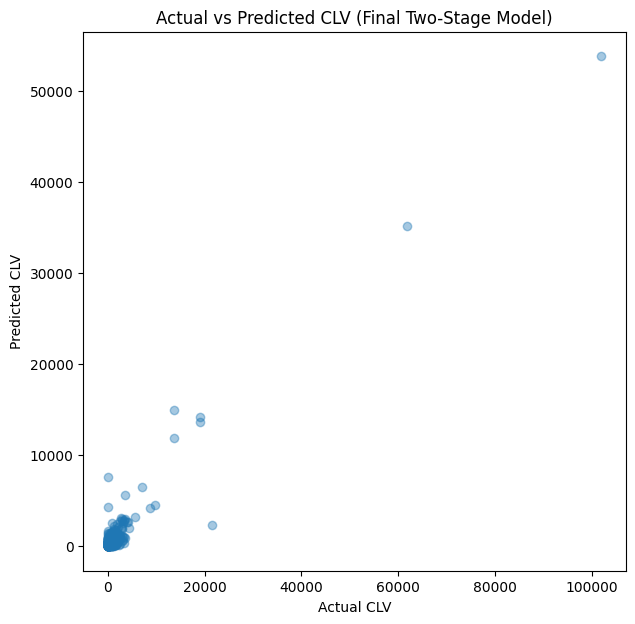

In [20]:
plt.figure(figsize=(7, 7))
plt.scatter(results_df["actual_clv"], results_df["predicted_clv_two_stage"], alpha=0.4)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV (Final Two-Stage Model)")
plt.show()

### Interpretation

The scatter plot should show a much better fit for low- and medium-value customers relative to the earlier single-stage model.

Some underprediction of extreme high-value customers may remain, which is common in CLV systems due to the rarity and unpredictability of large future spenders.

Even so, the final model is substantially more useful for business purposes because it produces:
- more realistic expected value estimates
- better control of inactive customers
- lower overall prediction error

## 16. Feature Importance of Conditional Regression Model

Feature importance is reviewed using the final regression component of the two-stage system.

This helps identify which historical customer behaviors matter most for future value estimation among returning customers.

In [21]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,total_revenue,0.309561
10,active_days,0.094856
2,total_items,0.076432
1,total_orders,0.075697
9,avg_revenue_per_order,0.065848
12,revenue_per_day,0.052392
5,unique_products,0.038938
14,recency_ratio,0.038123
11,avg_days_between_orders,0.037652
7,customer_tenure_days,0.037454


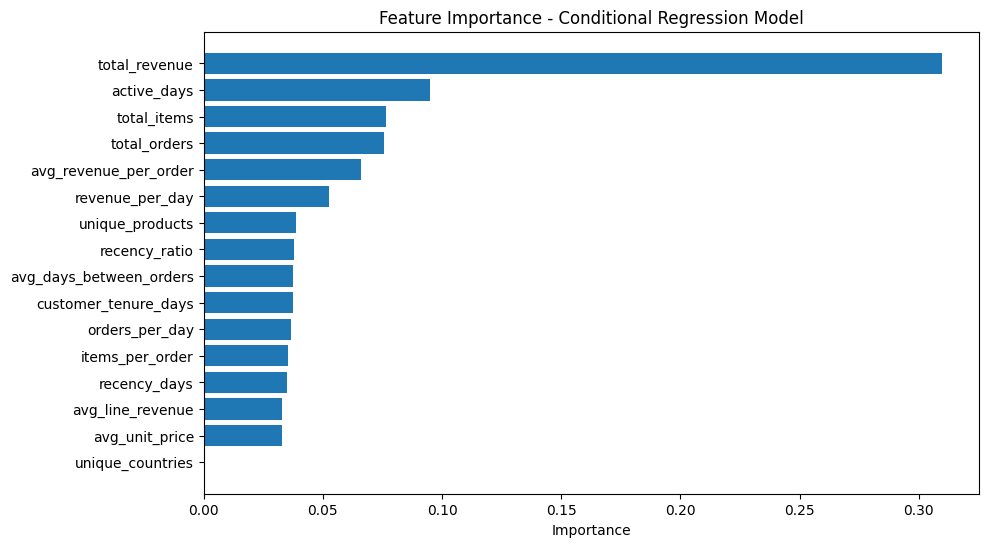

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Conditional Regression Model")
plt.xlabel("Importance")
plt.show()

### Interpretation

The most important features in the final regression stage reveal what drives customer value among returning customers.

Features related to:
- historical spend
- engagement consistency
- relationship duration
- purchasing intensity

are expected to play the strongest role.

This provides business insight into what distinguishes stronger future customers from weaker ones.

## 17. SHAP Explainability for Final Regression Stage

SHAP values are used to understand how historical customer features contribute to the final conditional value predictions.

This improves:
- interpretability
- stakeholder trust
- deployment readiness

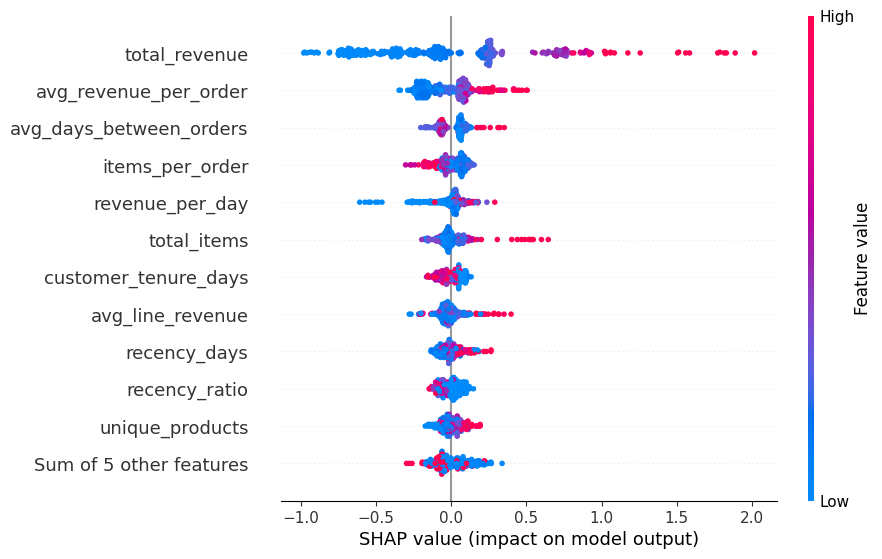

In [23]:
explainer = shap.Explainer(reg_model, X_train_r)
shap_values = explainer(X_test_r)

shap.plots.beeswarm(shap_values, max_display=12)

### Interpretation

The SHAP analysis helps verify that the final model is learning patterns consistent with business intuition.

For example, customers who:
- spent more historically
- purchased more consistently
- remained active over a longer period

should generally receive higher predicted future value.

This is important because explainability makes the model easier to trust and defend in business settings.

## 18. Save Final Model Artifacts

The final deployment candidate consists of:
- the classification model
- the conditional regression model
- feature definitions
- performance metadata

These artifacts will be used later in API and dashboard deployment.

In [25]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(clf, models_dir / "clv_return_classifier.pkl")
joblib.dump(reg_model, models_dir / "clv_value_regressor.pkl")

metrics_payload = {
    "baseline_metrics": {
        "model": baseline_metrics["model"],
        "mae_raw": float(baseline_metrics["mae_raw"]),
        "rmse_raw": float(baseline_metrics["rmse_raw"]),
        "r2_log": float(baseline_metrics["r2_log"]),
    },
    "single_stage_metrics": {
        "model": xgb_metrics["model"],
        "mae_raw": float(xgb_metrics["mae_raw"]),
        "rmse_raw": float(xgb_metrics["rmse_raw"]),
        "r2_log": float(xgb_metrics["r2_log"]),
    },
    "final_two_stage_metrics": {
        "model": final_metrics["model"],
        "mae_raw": float(final_metrics["mae_raw"]),
        "rmse_raw": float(final_metrics["rmse_raw"]),
    },
    "feature_columns": feature_cols,
    "final_prediction_formula": "P(return) * E(value | return)"
}

with open(models_dir / "clv_two_stage_metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=2)

print("Final two-stage models and metrics saved.")

Final two-stage models and metrics saved.
